## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Angela Wu: Conceptualization, Data curation, Software, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [2]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset #1

In [ ]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Dataset #4
Asthma Datasets for New York, San Francisco, and Houston

In [12]:
# load the file from directory
ny_asthma_data = 'data/00-raw/NYC EH Data Portal - Adults with a recent asthma attack (filtered).csv'

df = pd.read_csv(ny_asthma_data)
# to keep only data for New York City
new_df = df[df['Geography']=='New York City']

new_df = new_df.rename(columns={
    "TimePeriod":"year",
    "GeoTypeDesc":"geotype",
    "GeoID":"geoID",
    "GeoRank":"geoRank",
    "BoroID":"boroID",
    "Borough":"borough",
    "Geography":"geography",
    "Area":"area",
    "Number":"number",
    "Percent":"percentage",
    "Age-adjusted percent":"agePercent"
})

# keep only relevant columns
new_df = new_df.drop(['geotype', 'geoID', 'geoRank', 'boroID', 'borough', 'geography', 
                      'area', 'agePercent', 'number'], axis=1)
# drop data before 2010
new_df = new_df.drop([78, 84, 90, 96, 102, 108])

# This pattern looks for: (digits + decimal + digits) OR (just digits)
new_df['percentage'] = new_df['percentage'].astype(str).str.extract(r'(\d+\.\d+|\d+)').astype(float)
print(new_df.dtypes)
new_df['city'] = 'new york'

new_df 

year            int64
percentage    float64
dtype: object


,year,percentage,city
0,2022,4.3,new york
6,2021,4.9,new york
12,2020,3.8,new york
18,2019,4.5,new york
24,2018,4.4,new york
30,2017,4.4,new york
36,2016,4.8,new york
42,2015,6.0,new york
48,2014,3.7,new york
54,2013,3.9,new york


In [13]:
import requests
import io

# URL (CSV format)
sf_asthma_url = "https://data.chhs.ca.gov/dataset/01f456c3-db34-44f2-a52c-6811bef8ba6d/resource/a440b99b-ccc6-473c-bea1-2baf36b05dbe/download/current-asthma-prevalence-by-county-2015_2022.csv"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(sf_asthma_url, headers=headers)

if response.status_code == 200:
    # ADD encoding='ISO-8859-1' OR encoding='cp1252'
    sf_df = pd.read_csv(io.BytesIO(response.content), encoding='ISO-8859-1')
    sf_df = sf_df.drop(['STRATA', '95% CONFIDENCE INTERVAL', 'COUNTIES GROUPED', 'COMMENT'], axis=1)

    sf_df = sf_df.rename(columns={'COUNTY':'city', 'YEARS':'year', 'AGE GROUP':'age', 'CURRENT PREVALENCE':'percentage'})
    sf_df = sf_df[sf_df['city']=='San Francisco']
    sf_df = sf_df[sf_df['age']=='18+ years']
    sf_df['city'] = 'san francisco'
    sf_df = sf_df.reset_index(drop=False)
    
    sf_df.loc[sf_df['year'].str.contains('2015'), 'year'] = '2015'
    sf_df.loc[sf_df['year'].str.contains('2017'), 'year'] = '2017'
    sf_df.loc[sf_df['year'].str.contains('2019'), 'year'] = '2019'
    sf_df.loc[sf_df['year'].str.contains('2021'), 'year'] = '2021'

    # Using the trick from before to just take the first 4 characters
    sf_df['year'] = sf_df['year'].str[:4].astype(int)
    
    # Create a copy of the dataframe to represent the "even" years
    even_years_df = sf_df.copy()
    
    # Add 1 to the year column (e.g., 2015 becomes 2016)
    even_years_df['year'] = even_years_df['year'] + 1
    
    # Combine the original "odd" years with the new "even" years
    sf_df = pd.concat([sf_df, even_years_df])
    
    # Sort by year so it's chronological and reset the index
    sf_df = sf_df.sort_values('year').reset_index(drop=True)
    sf_df = sf_df.drop(['index','age'], axis=1)
else:
    print(f"Failed to download. Status code: {response.status_code}")

sf_df

,city,year,percentage
0,san francisco,2015,9.1
1,san francisco,2016,9.1
2,san francisco,2017,7.7
3,san francisco,2018,7.7
4,san francisco,2019,8.0
5,san francisco,2020,8.0
6,san francisco,2021,8.8
7,san francisco,2022,8.8


In [14]:
# load the file from directory
ht_asthma_data = 'data/00-raw/Texas_Adults_With_Current_Asthma.xlsx'

ht_df = pd.read_excel(ht_asthma_data)
ht_df['city'] = 'houston'
ht_df['percentage'] = ht_df['percentage']*100
ht_df = ht_df.drop(['population', 'number'], axis=1)
ht_df

,year,percentage,city
0,2014,8.5,houston
1,2015,8.8,houston
2,2016,8.8,houston
3,2017,8.3,houston
4,2018,9.0,houston
5,2019,8.8,houston
6,2020,9.1,houston
7,2021,10.0,houston
8,2022,9.3,houston


In [15]:
asthma_df = pd.concat([sf_df, new_df, ht_df], ignore_index=True)

# Sort by year for sanity
asthma_df = asthma_df.sort_values('year')
asthma_df = asthma_df.reset_index(drop=False)
asthma_df = asthma_df.drop('index', axis=1)
asthma_df

,city,year,percentage
0,new york,2010,3.7
1,new york,2011,4.5
2,new york,2012,4.6
3,new york,2013,3.9
4,houston,2014,8.5
5,new york,2014,3.7
6,san francisco,2015,9.1
7,houston,2015,8.8
8,new york,2015,6.0
9,houston,2016,8.8


In [17]:
asthma_df.describe()

,year,percentage
count,30.000000,30.000000
mean,2017.266667,6.843333
std,3.331494,2.234939
min,2010.000000,3.700000
25%,2015.000000,4.500000
50%,2017.500000,7.850000
75%,2020.000000,8.800000
max,2022.000000,10.000000


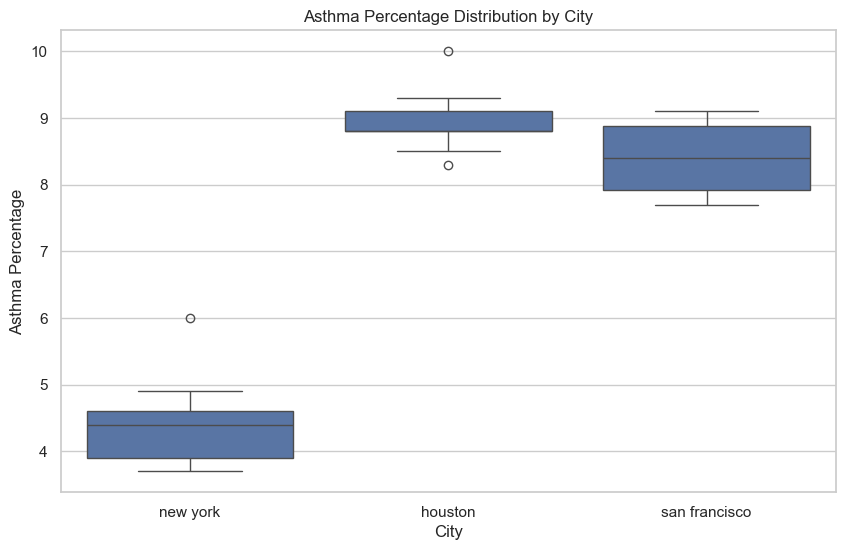

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=asthma_df, x='city', y='percentage')
plt.title('Asthma Percentage Distribution by City')
plt.ylabel('Asthma Percentage')
plt.xlabel('City')
plt.show()

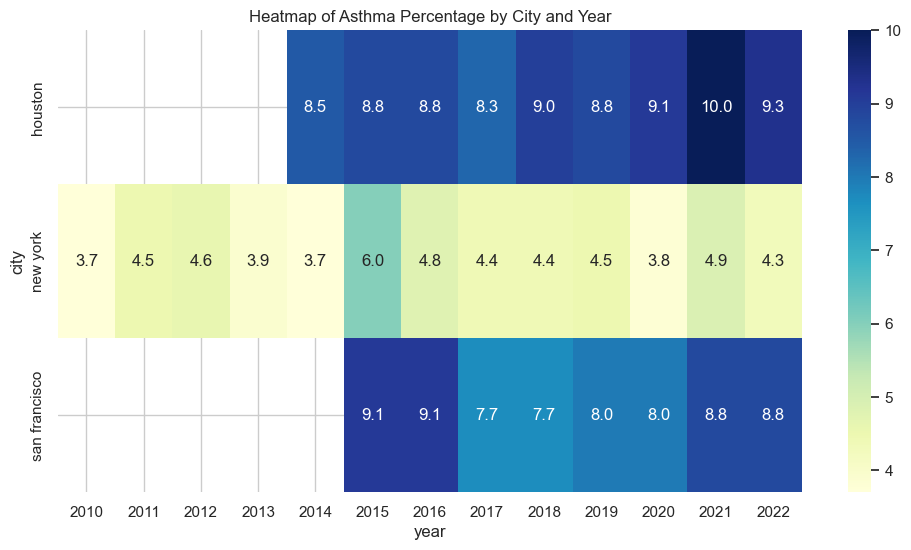

In [22]:
heatmap_data = asthma_df.pivot(index='city', columns='year', values='percentage')

plt.figure(figsize=(12, 6))
# Using annot=True to show the actual values in the squares
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Heatmap of Asthma Percentage by City and Year')
plt.show()

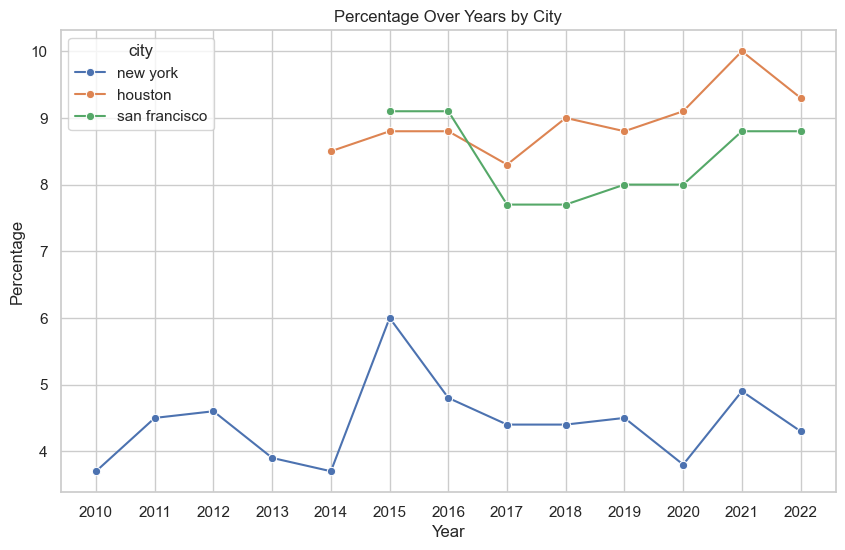

In [19]:
sns.set_theme(style="whitegrid")

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=asthma_df, x='year', y='percentage', hue='city', marker='o')

# Add titles and labels for clarity
plt.title('Percentage Over Years by City')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(asthma_df['year'].unique())

plt.show()

### Dataset #5
Public Transport Ridership Datasets for New York, San Francisco, Houston

In [36]:
# load the file from directory
ny_transport_data = 'data/00-raw/MTA_Monthly_Ridership___Traffic_Data__Beginning_January_2008_20260301.csv'

df = pd.read_csv(ny_transport_data)

ny_none = df[df['Ridership']=='0']

ny_null = df.isnull().sum()
print(ny_none)
print(ny_null)

         Month Agency Ridership
0   2025-12-01     BT         0
8   2025-11-01     BT         0
16  2025-10-01     BT         0
24  2025-09-01     BT         0
Month        0
Agency       0
Ridership    0
dtype: int64


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### EDA on Air Quality Data - exploring trends over time and comparing air quality accross cities

This EDA examines long-term trends in NO₂ and PM2.5 across three major U.S. metropolitan areas- SF, NY and Houston. By focusing on annual summary statistics, the aim is to compare overall exposure levels across cities and evaluate how pollution patterns have evolved over time.

In [17]:
# load csv file 
air = pd.read_csv("data/01-interim/air_quality_tidy.csv")
air.head()

,cbsa,pollutant,trend_stat,sites,year,value
0,"Albany, GA",PM2.5,Weighted Annual Mean,1.0,2000,16.60
1,"Albany, GA",PM2.5,98th Percentile,1.0,2000,38.00
2,"Albany-Schenectady-Troy, NY",O3,4th Max,2.0,2000,0.07
3,"Albany-Schenectady-Troy, NY",PM2.5,Weighted Annual Mean,1.0,2000,12.40
4,"Albany-Schenectady-Troy, NY",PM2.5,98th Percentile,1.0,2000,30.00


In [ ]:
# filter dataset to only be relevant cities (SF, NY and Houston) and relevant pollutants (no2 and pm2.5)
cities = [
    "San Francisco-Oakland-Hayward, CA",
    "New York-Newark-Jersey City, NY-NJ-PA",
    "Houston-The Woodlands-Sugar Land, TX"
]


air_subset = air[
    (air["cbsa"].isin(cities)) &
    (
        ((air["pollutant"] == "NO2") & (air["trend_stat"] == "Annual Mean")) |
        ((air["pollutant"] == "PM2.5") & (air["trend_stat"] == "Weighted Annual Mean"))
    )
]

# see shape, stats and first few rows of filtered dataset
print(air_subset.head())
print(air_subset.shape)
print(air_subset.describe())


                                      cbsa pollutant            trend_stat  \
384   Houston-The Woodlands-Sugar Land, TX       NO2           Annual Mean   
388   Houston-The Woodlands-Sugar Land, TX     PM2.5  Weighted Annual Mean   
613  New York-Newark-Jersey City, NY-NJ-PA       NO2           Annual Mean   
617  New York-Newark-Jersey City, NY-NJ-PA     PM2.5  Weighted Annual Mean   
796      San Francisco-Oakland-Hayward, CA       NO2           Annual Mean   

     sites  year  value  
384   10.0  2000   12.0  
388    3.0  2000   13.1  
613    4.0  2000   26.0  
617   10.0  2000   14.2  
796    6.0  2000   16.0  
(144, 6)
            sites         year       value
count  144.000000   144.000000  144.000000
mean     6.166667  2011.500000   11.325000
std      2.862831     6.946348    4.030903
min      3.000000  2000.000000    6.000000
25%      4.000000  2005.750000    8.475000
50%      5.000000  2011.500000   11.000000
75%     10.000000  2017.250000   13.000000
max     10.000000  202

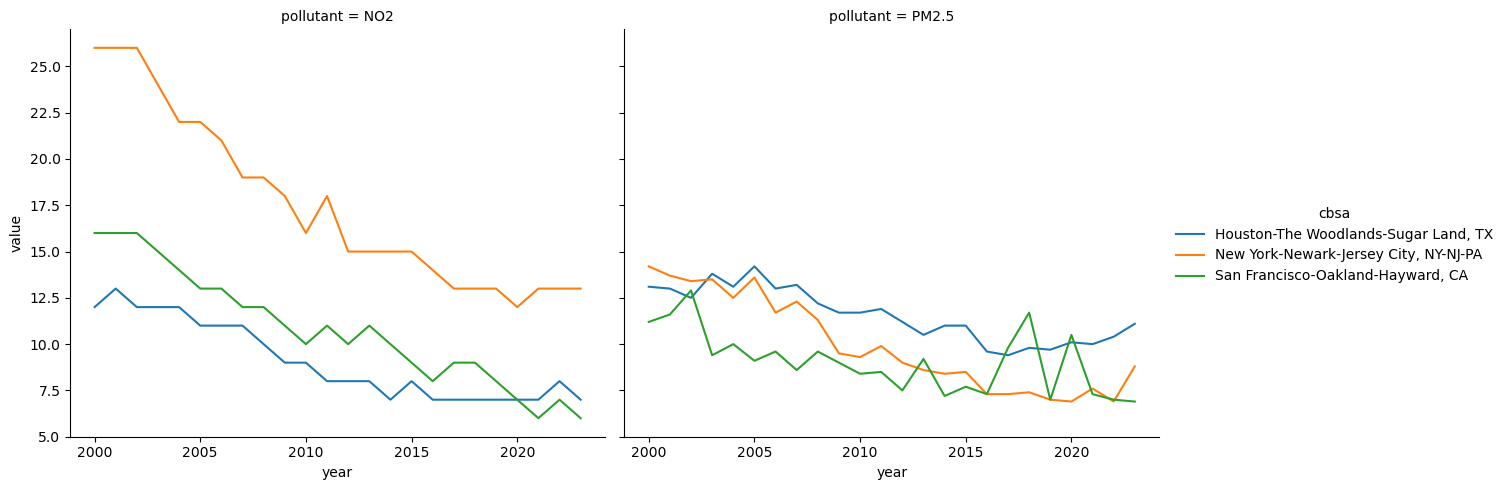

In [ ]:
# trends of no2 and pm2.5 over time, comparing across 2 cities.
sns.relplot(
    data=air_subset,
    x="year",
    y="value",
    col="pollutant",
    hue="cbsa",
    kind="line",
    height=5,
    aspect=1.2
)

plt.show()

The time series plots show a downward trend in NO2 across all three cities from 2000 onward. New York begins with the highest NO2 levels but experiences substantial declines over time, suggesting improvements in emissions controls or traffic-related regulations. 

PM2.5 also declines over time, though the trend appears more gradual and less uniform. Houston shows slightly more fluctuation in particulate levels, while San Francisco keeps relatively lower concentrations throughout the period. Overall, both pollutants demonstrate long-term improvement.

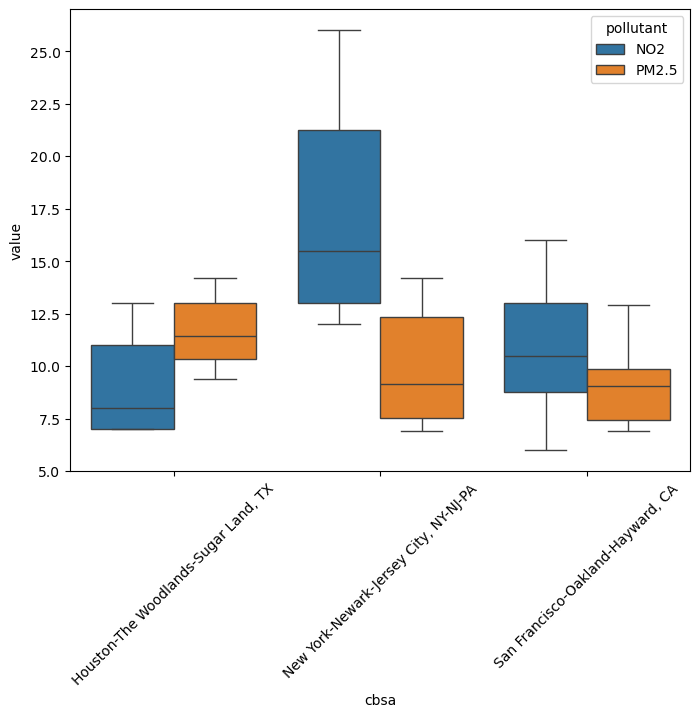

In [ ]:
# distribution comparison between cities 
plt.figure(figsize=(8,6))
sns.boxplot(
    data=air_subset,
    x="cbsa",
    y="value",
    hue="pollutant"
)
plt.xticks(rotation=45)
plt.show()

The boxplot highlights differences in pollution levels across cities. For NO2, New York consistently shows the highest values, followed by Houston, while San Francisco has the lowest median levels.
For PM2.5, the differences between cities are smaller, though Houston and New York show slightly higher variability compared to San Francisco. Overall, NO2 appears to vary more dramatically across cities than PM2.5.

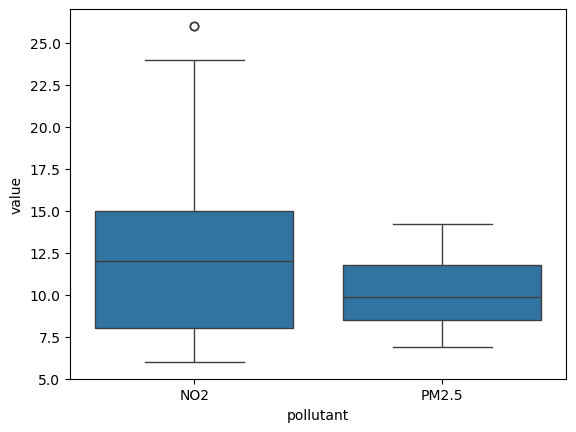

In [ ]:
#check for outliers
sns.boxplot(
    data=air_subset,
    x="pollutant",
    y="value"
)
plt.show()

The NO2 distribution contains one noticeable high outlier. This value likely corresponds to an early-year observation when NO2 concentrations were substantially higher, particularly in New York. 

PM2.5 does not exhibit extreme outliers, and its distribution appears more tightly clustered.

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them